In [1]:
from pathlib import Path

import nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as widgets
import numpy as np
from IPython.display import display

from resources.cut_off_edges import cut_off_edges
from resources.find_x import (
    calculate_x_profile,
    find_x_area_center, find_x_area_center_split,
)
from resources.find_y import (
    calculate_y_profile,
    find_y_argmax, find_y_area_center,
)
from resources.find_z import (
    calculate_z_profile,
    find_z_argmax, find_z_area_center,
)
from resources.rotate_image import rotate_volume
from resources.standarize_image import standardize_image
from resources.find_pitch_error_y_y import find_pitch_error, create_rotation_y_profile

In [2]:
def show_view():
    angle_slider = widgets.FloatSlider(
    value=0,
    min=-180,
    max=180,
    step=1,
    description="kąt:",
    continuous_update=False,
    )

    center_x_slider = widgets.IntSlider(
        value=x_centre,
        min=0,
        max=x_size - 1,
        step=1,
        description="center X:",
        continuous_update=False,
    )

    center_y_slider = widgets.IntSlider(
        value=y_centre,
        min=0,
        max=y_size - 1,
        step=1,
        description="center Y:",
        continuous_update=False,
    )

    center_z_slider = widgets.IntSlider(
        value=z_centre,
        min=0,
        max=z_size - 1,
        step=1,
        description="center Z:",
        continuous_update=False,
    )

    x_slice_slider = widgets.IntSlider(
        value=x_centre,
        min=0,
        max=x_size - 1,
        step=1,
        description="slice X:",
        continuous_update=False,
    )


    def show_rotation(
        angle,
        center_x,
        center_y,
        center_z,
        x_slice,
    ):
        volume = processed_image.get_fdata(dtype=np.float32)

        center = (
            center_x,
            center_y,
            center_z,
        )

        rotated_image = rotate_volume(
            image=processed_image,
            angle=angle,
            axis="x",
            center=center,
        )

        rotated_volume = rotated_image.get_fdata(
            dtype=np.float32
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(14, 7),
        )

        # Oryginał - widok YZ
        axes[0].imshow(
            volume[x_slice, :, :].T,
            origin="lower",
            cmap="gray",
        )

        axes[0].axvline(
            center_y,
            linestyle="--",
        )

        axes[0].axhline(
            center_z,
            linestyle="--",
        )

        axes[0].scatter(
            center_y,
            center_z,
            marker="+",
            s=200,
        )

        axes[0].set_title(
            f"Oryginał\n"
            f"slice X = {x_slice}"
        )

        axes[0].set_xlabel("Y")
        axes[0].set_ylabel("Z")

        # Po obrocie - widok YZ
        axes[1].imshow(
            rotated_volume[x_slice, :, :].T,
            origin="lower",
            cmap="gray",
        )

        axes[1].axvline(
            center_y,
            linestyle="--",
        )

        axes[1].axhline(
            center_z,
            linestyle="--",
        )

        axes[1].scatter(
            center_y,
            center_z,
            marker="+",
            s=200,
        )

        axes[1].set_title(
            f"Obrót wokół X: {angle:.1f}°\n"
            f"center = "
            f"({center_x}, {center_y}, {center_z})"
        )

        axes[1].set_xlabel("Y")
        axes[1].set_ylabel("Z")

        plt.tight_layout()
        plt.show()


    interactive_view = widgets.interactive(
        show_rotation,
        angle=angle_slider,
        center_x=center_x_slider,
        center_y=center_y_slider,
        center_z=center_z_slider,
        x_slice=x_slice_slider,
    )

    display(interactive_view)

In [3]:
PROJECT_DIR = Path.cwd().parents[2]

DATA_DIR = PROJECT_DIR / "data"
SRC_DIR = PROJECT_DIR / "src"

NIFTI_DIR = PROJECT_DIR / "data" / "niftis"

# UID obrazu do testowania
UID = "ahulwjti"

In [4]:
file_path = NIFTI_DIR / f"{UID}.nii.gz"

image = nib.load(file_path)
# Obróbka obrazu; funkcja zwraca obiekt NIfTI
processed_image = cut_off_edges(image)
processed_image = cut_off_edges(processed_image,x_left=35,x_right=35,y_front=40,y_back=40,z_down=30,z_up=30)
# processed_image = cut_off_edges(processed_image, x_left=30, x_right=30, y_front=30, y_back=30, z_down=20, z_up=25)
# Standaryzacja obrazu
processed_image = standardize_image(processed_image, percent_top=0.02)

volume = processed_image.get_fdata(dtype=np.float32)

x_size, y_size, z_size = volume.shape

print("UID:", UID)
print("Shape:", volume.shape)
print("Voxel size:", image.header.get_zooms()[:3])
print("Orientation:", nib.aff2axcodes(image.affine))

UID: ahulwjti
Shape: (70, 80, 60)
Voxel size: (np.float32(2.46), np.float32(2.46), np.float32(2.46))
Orientation: ('R', 'A', 'S')


In [5]:

x_profile = calculate_x_profile(volume)
y_profile = calculate_y_profile(volume)
z_profile = calculate_z_profile(volume)

x_centre = int(find_x_area_center(x_profile))
y_centre = int(find_y_area_center(y_profile))
z_centre = int(find_z_area_center(z_profile))

xyz_centre = (
    x_centre,
    y_centre,
    z_centre,
)

print()
print("Wyznaczony środek:")
print("X:", x_centre)
print("Y:", y_centre)
print("Z:", z_centre)


Wyznaczony środek:
X: 35
Y: 40
Z: 31


In [6]:
pitch_error = find_pitch_error(processed_image)
pitch_error

-17

In [7]:
show_view()

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='kąt:', max=180.0, min=-180.…

([<matplotlib.axis.XTick at 0x218f34c09e0>,
 [Text(0, 0, '0'),
  Text(30, 0, '30'),
  Text(60, 0, '60'),
  Text(90, 0, '90'),
  Text(120, 0, '120'),
  Text(150, 0, '150'),
  Text(180, 0, '180'),
  Text(210, 0, '210'),
  Text(240, 0, '240'),
  Text(270, 0, '270'),
  Text(300, 0, '300'),
  Text(330, 0, '330'),
  Text(360, 0, '360')])

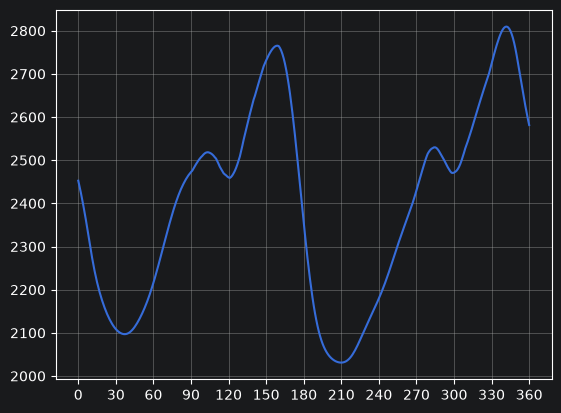

In [8]:
from resources.smooth_1d import smooth_1d
rotation_y_profile = create_rotation_y_profile(processed_image)
rotation_y_profile = smooth_1d(rotation_y_profile,window_size=19)
plt.plot(rotation_y_profile)
plt.grid()
plt.xticks(np.arange(0, len(rotation_y_profile), 30))